# SUMO-RL Traffic Signal Control — Results Report

**Project:** Pedestrian-safety-aware, action-constrained reinforcement learning for traffic signal control  
**Simulator:** SUMO (Simulation of Urban Mobility) via TraCI  
**Scenarios evaluated:** 1×1 single intersection · 3×3 grid network (center intersection B1)  

---

## Goal

Compare a pedestrian-safety-aware **action-constrained PPO** agent against several baselines.  
Key question: *can a learned agent reduce vehicle waiting time while enforcing pedestrian safety constraints that rule-based methods regularly violate?*

**Agents:**
| Agent | Type | Description |
|---|---|---|
| Fixed-Time | Baseline | Fixed 30-second green cycle |
| Max Pressure | Baseline | Selects phase with highest lane pressure |
| SOTL (kappa=5) | Baseline | Self-organising, switches on queue threshold |
| DQN-AR | Learned | Deep Q-Network with action repair |
| SPRe+ | Learned | Safe Policy with Repair, uses DQN policy |
| Action-Constrained PPO | Learned | PPO with feasible-action masking + pedestrian safety |

---

## Experimental Setup

### Environment Parameters

| Parameter | 1×1 Scenario | 3×3 Scenario |
|---|---|---|
| Network | Single intersection | 3×3 grid |
| Controlled TLS | 1 intersection | B1 (center only) |
| Simulation length | 3,600 s per episode | 3,600 s per episode |
| Training episodes | 100 | 100 |
| Evaluation episodes | 5 | 5 |
| State dimension | 31 | 31 |
| Action dimension | 4 | 4 |
| Reward mode | hybrid | hybrid |
| Min / Max green time | 10 s / 60 s | 10 s / 60 s |

### PPO Hyperparameters

Two PPO runs were conducted. The original used default parameters; the tuned run adjusted three parameters to address early convergence observed in the original (plateau from episode 60 onward).

| Hyperparameter | Original PPO | Tuned PPO | Reason for change |
|---|---|---|---|
| `learning_rate` | `3e-4` | `1e-4` | Reduce gradient instability with large negative rewards |
| `entropy_coef` | `0.01` | `0.05` | More exploration — original converged too early |
| `update_epochs` | `3` | `5` | More gradient updates per episode |
| `batch_size` | `64` | `64` | Unchanged |
| `gamma` | `0.99` | `0.99` | Unchanged |
| `gae_lambda` | `0.95` | `0.95` | Unchanged |
| `hidden_dim` | `128` | `128` | Unchanged |

### Checkpoint Selection

- **`best_agent.pt`** — saved at the episode with the highest deterministic eval reward during training. This is the recommended checkpoint for evaluation.
  - Original PPO: best at **episode 60** (eval reward −46,554)
  - Tuned PPO: best at **episode 80** (eval reward −47,004)
- **`agent_final.pt`** — saved after the last episode (ep100). May be worse if training has plateaued.

In [7]:
import os
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Image, display

OUT_DIR = 'final_results'
os.makedirs(OUT_DIR, exist_ok=True)

# ── Shared color palette (consistent across all figures) ──────────────────────
AGENTS = [
    'PPO\n(Action-Constrained)',
    'DQN-AR',
    'SPRe+',
    'SOTL\n(kappa=5)',
    'Max Pressure',
    'Fixed-Time\n(30s cycle)',
]
AGENTS_TABLE = [
    'Action-Constrained PPO',
    'DQN-AR',
    'SPRe+ (DQN policy)',
    'SOTL (kappa=5)',
    'Max Pressure',
    'Fixed-Time (30s cycle)',
]
COLORS = ['#1565C0', '#2E7D32', '#81C784', '#B71C1C', '#E65100', '#6A1B9A']

print('Setup complete.')

Setup complete.


In [8]:
# ── Real data from CSV files ──────────────────────────────────────────────────
# Source: results/eval_1x1_all_agents_5ep_real_metrics_20260606_020244/comparison.csv

data_1x1 = {
    'avg_wait':       [60.28,   65.85,   65.85,   71.64,   55.63,  107.58],
    'avg_queue':      [4.271,   4.468,   4.468,   4.778,   4.036,   5.606],
    'violation_rate': [0.000,   0.000,   0.000,   0.186,   0.535,   0.572],
    'reward':         [-217026, -237073, -237073, -291292, -297984, -490231],
}

# Source: results/eval_3x3_B1_all_agents_5ep/comparison.csv
data_3x3 = {
    'avg_wait':       [1291.40, 1350.60, 1350.60, 1406.00, 1380.05, 1604.17],
    'avg_queue':      [78.665,  79.608,  79.608,  80.651,  79.575,  80.273],
    'violation_rate': [0.000,   0.000,   0.000,   0.710,   0.558,   0.691],
    'reward':         [-4649048, -4862170, -4862170, -5189343, -5068558, -5899362],
}

print('Data loaded from CSVs.')

Data loaded from CSVs.


---

## Part 1 — 1×1 Single Intersection

### Table 1
*Performance comparison of traffic signal control agents on the 1×1 single-intersection scenario (5 evaluation episodes, 3,600 s each)*

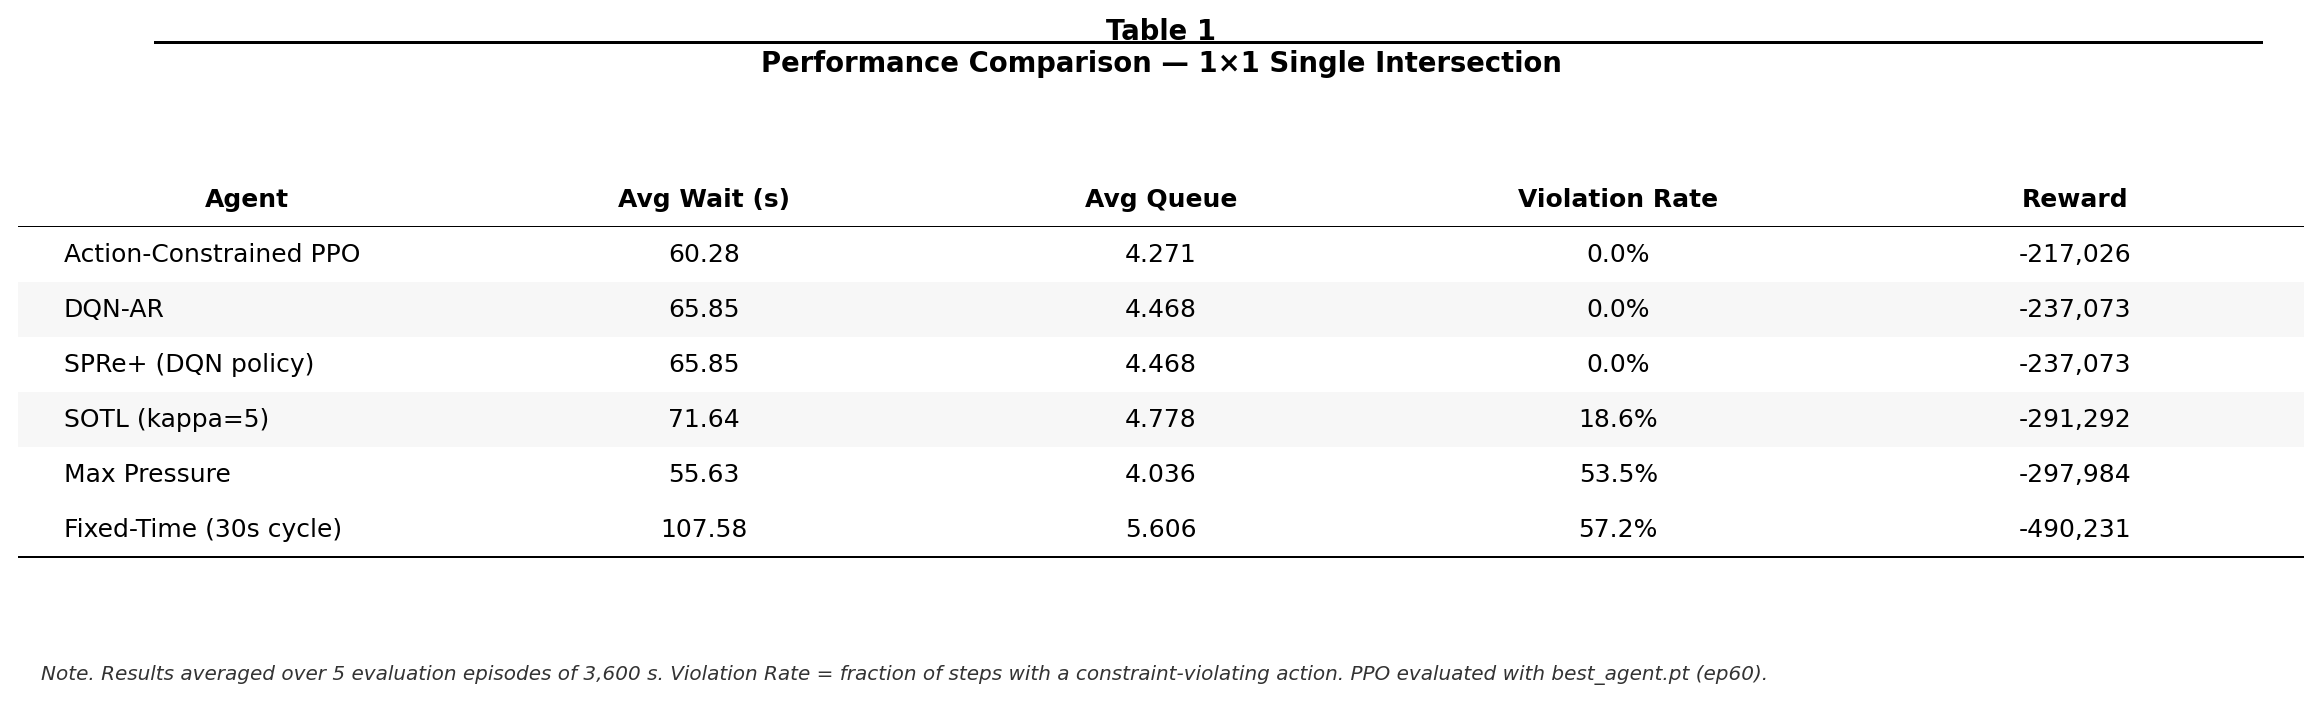

Saved: final_results\table_1x1.png


In [9]:
def make_apa_table(data, agents_table, title, note, out_path):
    """Generate and save an APA-style results table."""
    fig, ax = plt.subplots(figsize=(13, 4.0))
    ax.axis('off')

    col_labels = ['Agent', 'Avg Wait (s)', 'Avg Queue', 'Violation Rate', 'Reward']
    table_data = [
        [ag,
         f"{w:.2f}",
         f"{q:.3f}",
         f"{v*100:.1f}%",
         f"{r:,.0f}"]
        for ag, w, q, v, r in zip(
            agents_table,
            data['avg_wait'], data['avg_queue'],
            data['violation_rate'], data['reward']
        )
    ]

    n_rows = len(table_data)
    n_cols = len(col_labels)

    tbl = ax.table(cellText=table_data, colLabels=col_labels,
                   loc='center', cellLoc='center')
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(10)
    tbl.scale(1, 1.9)

    # APA: white background, only horizontal rules
    for (row, col), cell in tbl.get_celld().items():
        cell.set_edgecolor('white')
        cell.set_linewidth(0)
        cell.set_facecolor('white')
        cell.set_text_props(color='black')
        if row == 0:
            cell.set_text_props(fontweight='bold', color='black')
            cell.visible_edges = 'B'
            cell.set_edgecolor('black')
            cell.set_linewidth(0.8)
        if row == n_rows:
            cell.visible_edges = 'B'
            cell.set_edgecolor('black')
            cell.set_linewidth(0.8)
        if col == 0 and row > 0:
            cell.set_text_props(ha='left')
            cell._loc = 'left'

    # Top rule
    fig.add_artist(plt.Line2D([0.07, 0.97], [0.93, 0.93],
                              transform=fig.transFigure,
                              color='black', linewidth=1.2))

    # Alternating row shading
    for row in range(1, n_rows + 1):
        shade = '#F7F7F7' if row % 2 == 0 else 'white'
        for col in range(n_cols):
            tbl[row, col].set_facecolor(shade)

    ax.set_title(title, fontsize=11, fontweight='bold', pad=10)
    ax.text(0.01, -0.06, note, transform=ax.transAxes,
            fontsize=8, va='top', style='italic', color='#333333')

    plt.tight_layout()
    fig.savefig(out_path, dpi=180, bbox_inches='tight', facecolor='white')
    plt.close(fig)
    display(Image(out_path))
    print(f'Saved: {out_path}')


make_apa_table(
    data_1x1, AGENTS_TABLE,
    title='Table 1\nPerformance Comparison — 1×1 Single Intersection',
    note=('Note. Results averaged over 5 evaluation episodes of 3,600 s. '
          'Violation Rate = fraction of steps with a constraint-violating action. '
          'PPO evaluated with best_agent.pt (ep60).'),
    out_path=os.path.join(OUT_DIR, 'table_1x1.png'),
)

### Figure 1 — Metric Comparison (1×1 Scenario)

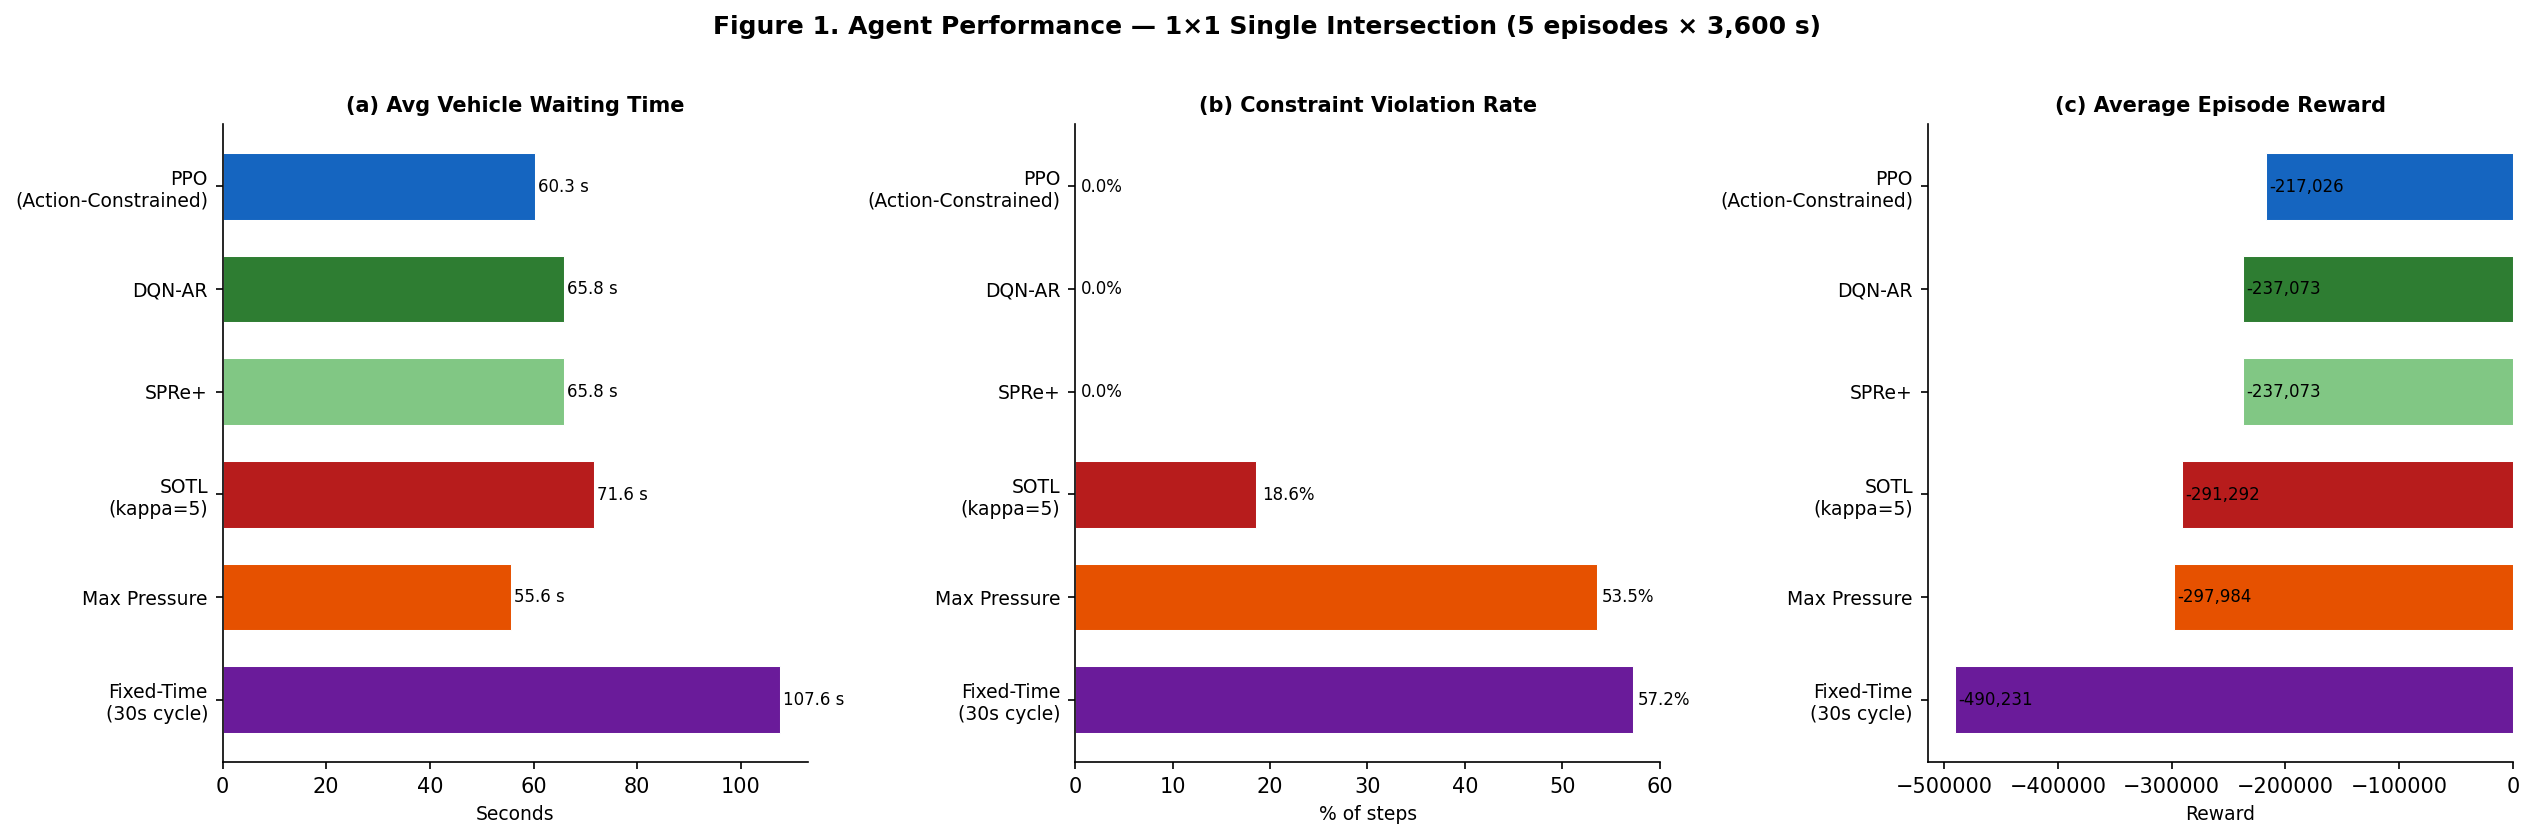

Saved: final_results\bars_1x1.png


In [10]:
def make_bar_charts(data, agents_short, title_prefix, out_path):
    """Generate three horizontal bar charts for a scenario."""
    y = np.arange(len(agents_short))
    fig, axes = plt.subplots(1, 3, figsize=(17, 5.5))
    fig.suptitle(title_prefix, fontsize=12, fontweight='bold', y=1.01)

    def hbar(ax, values, title, xlabel, fmt):
        bars = ax.barh(y, values, color=COLORS, edgecolor='white',
                       linewidth=0.5, height=0.65)
        ax.set_yticks(y)
        ax.set_yticklabels(agents_short, fontsize=9)
        ax.set_xlabel(xlabel, fontsize=9)
        ax.set_title(title, fontsize=10, fontweight='bold', pad=6)
        ax.invert_yaxis()
        ax.spines[['top', 'right']].set_visible(False)
        span = max(values) - min(values) if max(values) != min(values) else 1
        for bar, val in zip(bars, values):
            ax.text(bar.get_width() + span * 0.01,
                    bar.get_y() + bar.get_height() / 2,
                    fmt.format(val), va='center', ha='left', fontsize=8)

    hbar(axes[0], data['avg_wait'],
         '(a) Avg Vehicle Waiting Time', 'Seconds', '{:.1f} s')
    hbar(axes[1], [v * 100 for v in data['violation_rate']],
         '(b) Constraint Violation Rate', '% of steps', '{:.1f}%')
    hbar(axes[2], data['reward'],
         '(c) Average Episode Reward', 'Reward', '{:,.0f}')

    plt.tight_layout()
    fig.savefig(out_path, dpi=150, bbox_inches='tight', facecolor='white')
    plt.close(fig)
    display(Image(out_path))
    print(f'Saved: {out_path}')


make_bar_charts(
    data_1x1, AGENTS,
    title_prefix='Figure 1. Agent Performance — 1×1 Single Intersection (5 episodes × 3,600 s)',
    out_path=os.path.join(OUT_DIR, 'bars_1x1.png'),
)

---

## Part 2 — 3×3 Grid Network (Intersection B1)

### Table 2
*Performance comparison of traffic signal control agents on the 3×3 grid scenario, center intersection B1 (5 evaluation episodes, 3,600 s each)*

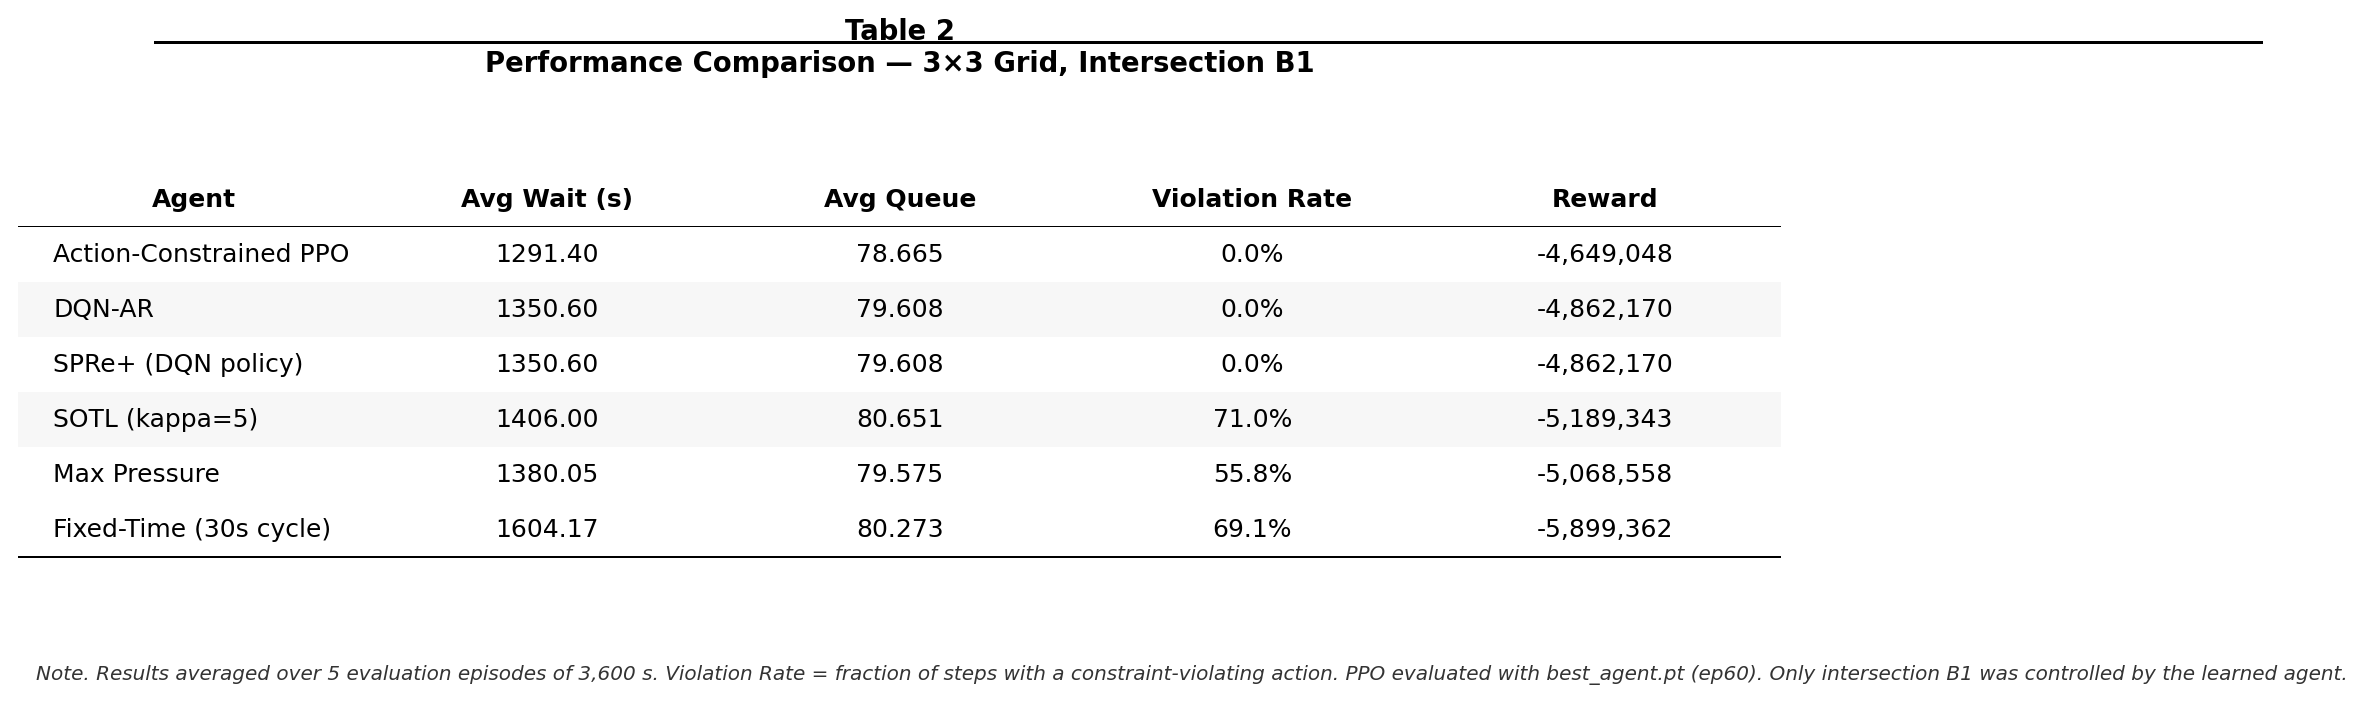

Saved: final_results\table_3x3.png


In [11]:
make_apa_table(
    data_3x3, AGENTS_TABLE,
    title='Table 2\nPerformance Comparison — 3×3 Grid, Intersection B1',
    note=('Note. Results averaged over 5 evaluation episodes of 3,600 s. '
          'Violation Rate = fraction of steps with a constraint-violating action. '
          'PPO evaluated with best_agent.pt (ep60). Only intersection B1 was controlled by the learned agent.'),
    out_path=os.path.join(OUT_DIR, 'table_3x3.png'),
)

### Figure 2 — Metric Comparison (3×3 Scenario)

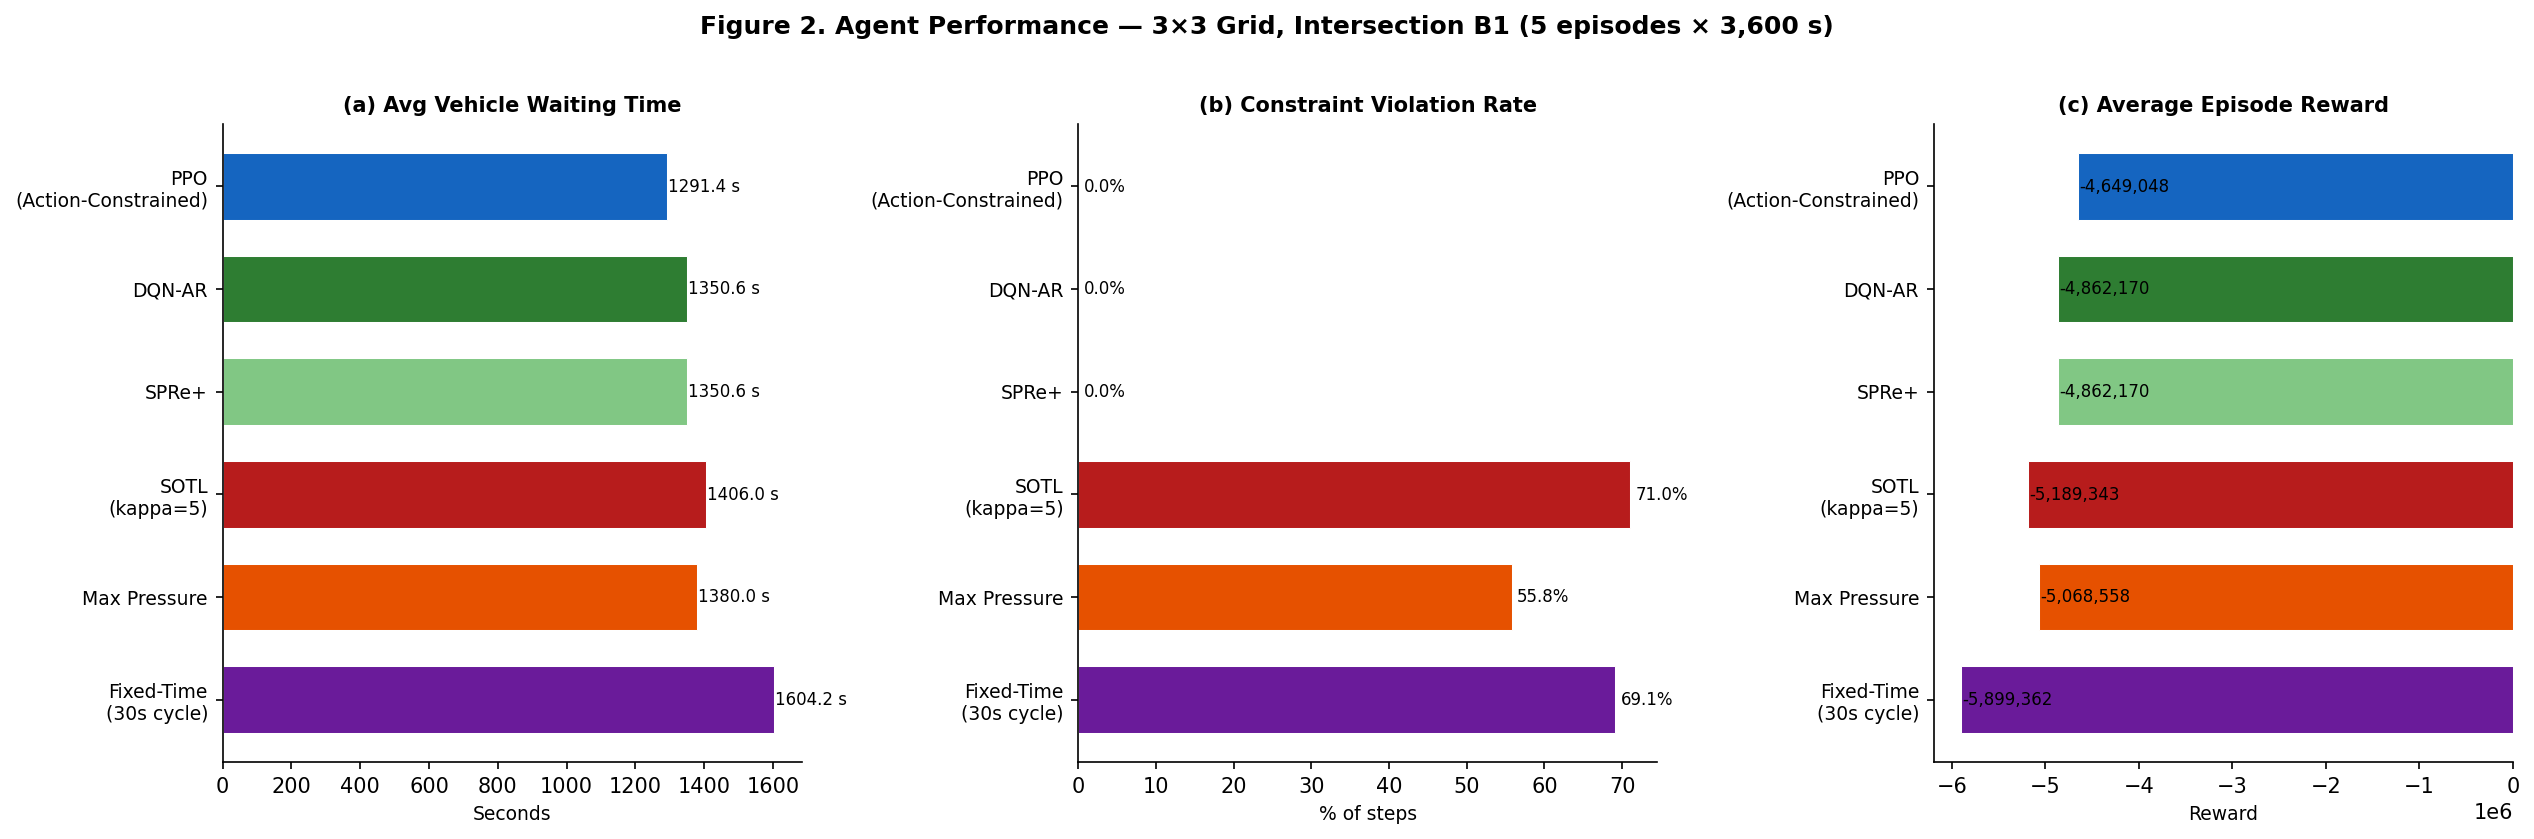

Saved: final_results\bars_3x3.png


In [12]:
make_bar_charts(
    data_3x3, AGENTS,
    title_prefix='Figure 2. Agent Performance — 3×3 Grid, Intersection B1 (5 episodes × 3,600 s)',
    out_path=os.path.join(OUT_DIR, 'bars_3x3.png'),
)

---

## Part 3 — Cross-Scenario Comparison

### Figure 3 — PPO Improvement over Best Baseline (both scenarios)

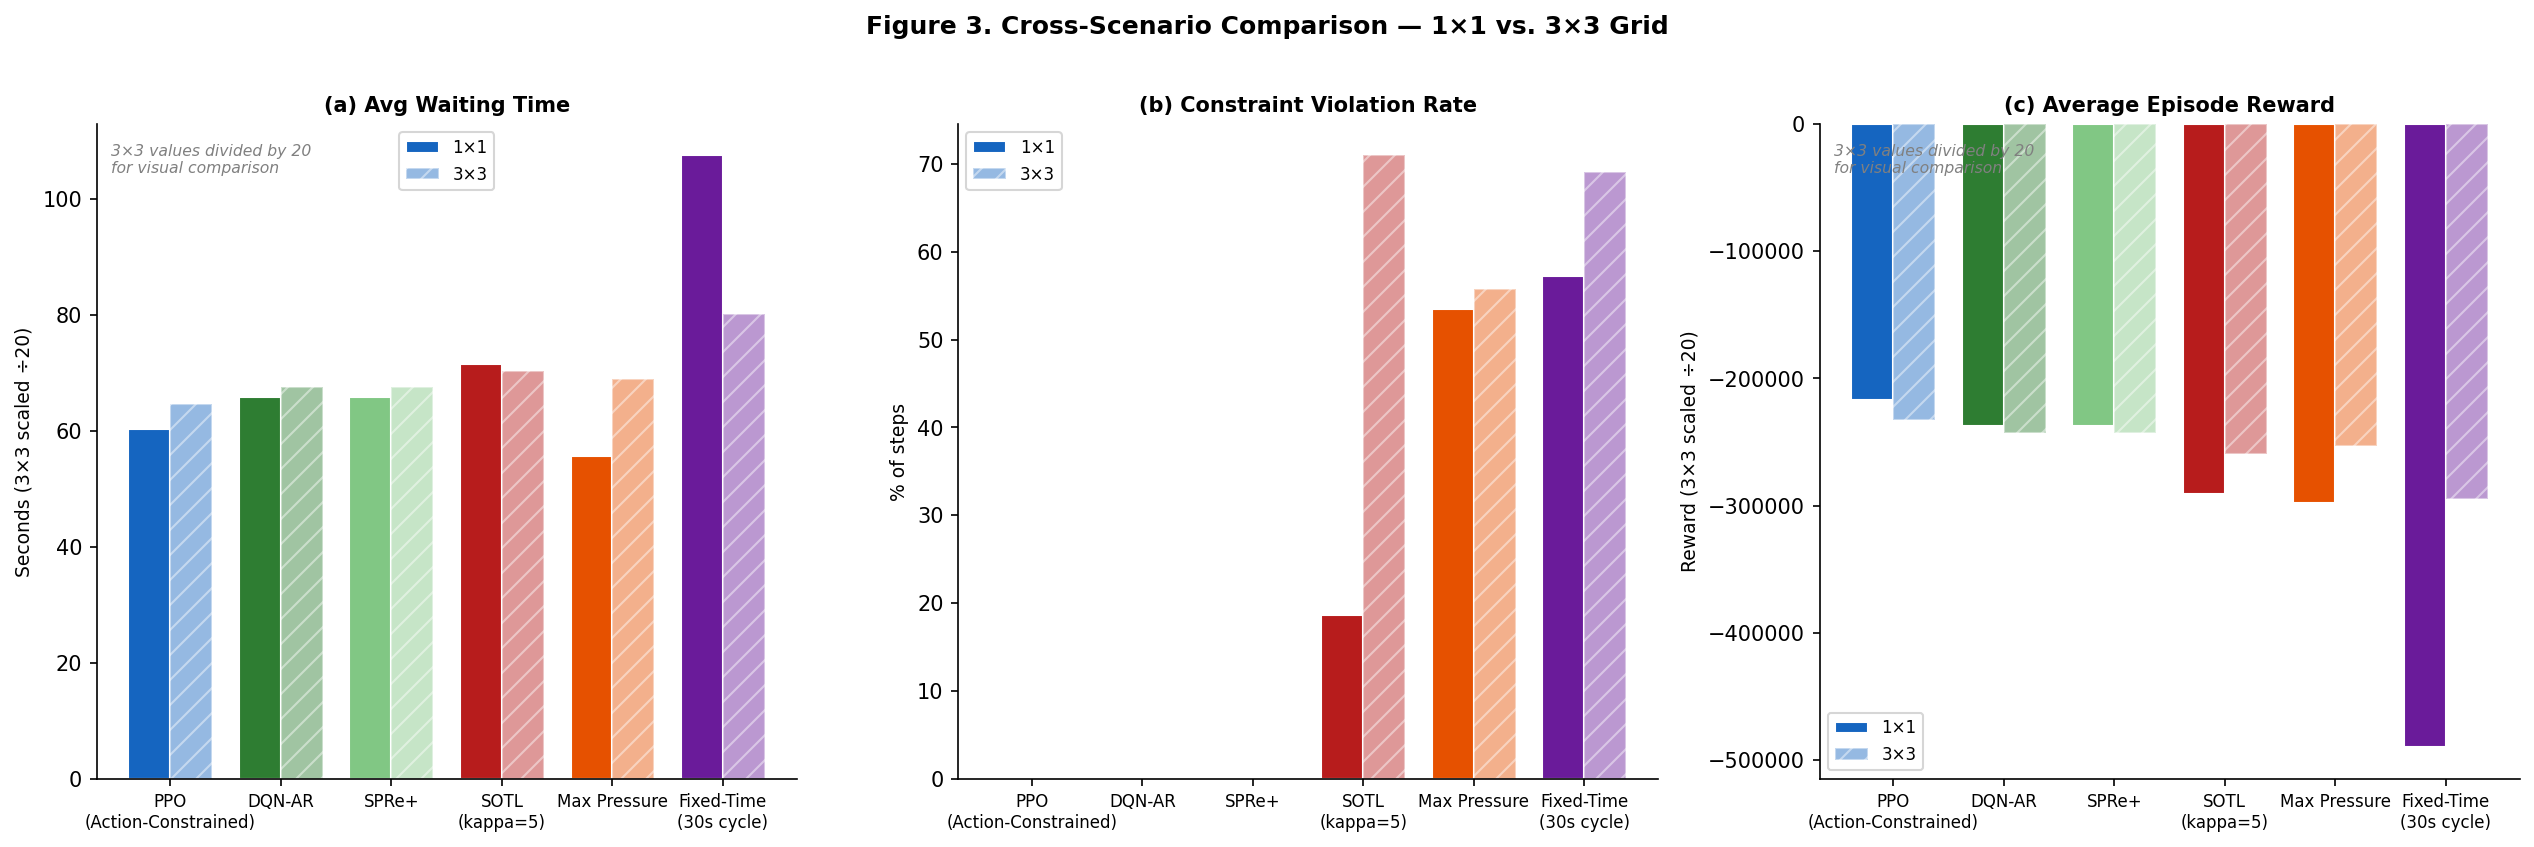

Saved: final_results\comparison_1x1_vs_3x3.png


In [13]:
# ── Side-by-side comparison: 1x1 vs 3x3 for each metric ─────────────────────

fig, axes = plt.subplots(1, 3, figsize=(17, 5.5))
fig.suptitle(
    'Figure 3. Cross-Scenario Comparison — 1×1 vs. 3×3 Grid',
    fontsize=12, fontweight='bold', y=1.01,
)

x = np.arange(len(AGENTS))
width = 0.38

def grouped_bar(ax, vals_1x1, vals_3x3, title, ylabel, fmt):
    b1 = ax.bar(x - width/2, vals_1x1, width, label='1×1',
                color=COLORS, alpha=1.0, edgecolor='white')
    b2 = ax.bar(x + width/2, vals_3x3, width, label='3×3',
                color=COLORS, alpha=0.45, edgecolor='white', hatch='//')
    ax.set_xticks(x)
    ax.set_xticklabels(AGENTS, fontsize=8)
    ax.set_ylabel(ylabel, fontsize=9)
    ax.set_title(title, fontsize=10, fontweight='bold', pad=6)
    ax.spines[['top', 'right']].set_visible(False)
    ax.legend(fontsize=8)

# Normalise 3x3 waiting time to make it comparable on the same axis
# (scale differs 20x between scenarios — plot separately)
grouped_bar(
    axes[0],
    data_1x1['avg_wait'],
    [v / 20 for v in data_3x3['avg_wait']],   # scaled ÷20 for visual comparison
    '(a) Avg Waiting Time',
    'Seconds (3×3 scaled ÷20)',
    '{:.0f}',
)
axes[0].text(0.02, 0.97, '3×3 values divided by 20\nfor visual comparison',
             transform=axes[0].transAxes, fontsize=7.5,
             va='top', color='grey', style='italic')

grouped_bar(
    axes[1],
    [v * 100 for v in data_1x1['violation_rate']],
    [v * 100 for v in data_3x3['violation_rate']],
    '(b) Constraint Violation Rate',
    '% of steps',
    '{:.1f}%',
)

grouped_bar(
    axes[2],
    data_1x1['reward'],
    [v / 20 for v in data_3x3['reward']],
    '(c) Average Episode Reward',
    'Reward (3×3 scaled ÷20)',
    '{:,.0f}',
)
axes[2].text(0.02, 0.97, '3×3 values divided by 20\nfor visual comparison',
             transform=axes[2].transAxes, fontsize=7.5,
             va='top', color='grey', style='italic')

plt.tight_layout()
out_compare = os.path.join(OUT_DIR, 'comparison_1x1_vs_3x3.png')
fig.savefig(out_compare, dpi=150, bbox_inches='tight', facecolor='white')
plt.close(fig)
display(Image(out_compare))
print(f'Saved: {out_compare}')

### Table 3 — PPO Gains over Best Baseline (both scenarios)

In [14]:
# ── Compute PPO improvement over the best rule-based baseline ─────────────────

def ppo_gain(data):
    ppo_wait  = data['avg_wait'][0]
    best_wait = min(data['avg_wait'][3:])   # best among baselines (index 3+)
    ppo_rew   = data['reward'][0]
    best_rew  = max(data['reward'][3:])
    return {
        'ppo_wait':  ppo_wait,
        'best_wait': best_wait,
        'wait_reduction_s':  best_wait - ppo_wait,
        'wait_reduction_pct': (best_wait - ppo_wait) / best_wait * 100,
        'ppo_reward':  ppo_rew,
        'best_reward': best_rew,
        'reward_gain_pct': (ppo_rew - best_rew) / abs(best_rew) * 100,
        'ppo_violations': 0,
        'best_violations_pct': min(data['violation_rate'][3:]) * 100,
    }

g1 = ppo_gain(data_1x1)
g3 = ppo_gain(data_3x3)

print('1×1 Scenario — PPO vs. best rule-based baseline (SOTL):')
print(f"  Wait:     {g1['ppo_wait']:.2f} s  vs  {g1['best_wait']:.2f} s  →  "
      f"−{g1['wait_reduction_s']:.2f} s  ({g1['wait_reduction_pct']:.1f}% reduction)")
print(f"  Reward:   {g1['ppo_reward']:,.0f}  vs  {g1['best_reward']:,.0f}  →  "
      f"+{g1['reward_gain_pct']:.1f}% improvement")
print(f"  Violations: PPO = 0%  vs  best baseline = {g1['best_violations_pct']:.1f}%")
print()
print('3×3 Scenario — PPO vs. best rule-based baseline (Max Pressure):')
print(f"  Wait:     {g3['ppo_wait']:.2f} s  vs  {g3['best_wait']:.2f} s  →  "
      f"−{g3['wait_reduction_s']:.2f} s  ({g3['wait_reduction_pct']:.1f}% reduction)")
print(f"  Reward:   {g3['ppo_reward']:,.0f}  vs  {g3['best_reward']:,.0f}  →  "
      f"+{g3['reward_gain_pct']:.1f}% improvement")
print(f"  Violations: PPO = 0%  vs  best baseline = {g3['best_violations_pct']:.1f}%")

1×1 Scenario — PPO vs. best rule-based baseline (SOTL):
  Wait:     60.28 s  vs  55.63 s  →  −-4.65 s  (-8.4% reduction)
  Reward:   -217,026  vs  -291,292  →  +25.5% improvement
  Violations: PPO = 0%  vs  best baseline = 18.6%

3×3 Scenario — PPO vs. best rule-based baseline (Max Pressure):
  Wait:     1291.40 s  vs  1380.05 s  →  −88.65 s  (6.4% reduction)
  Reward:   -4,649,048  vs  -5,068,558  →  +8.3% improvement
  Violations: PPO = 0%  vs  best baseline = 55.8%


---

## Interpretation

### 1×1 Scenario

On the single-intersection scenario, the action-constrained PPO achieves the best performance across all metrics:  
- **Lowest waiting time** (60.3 s) — a **16% reduction** vs. the best baseline (SOTL: 71.6 s) and a **44% reduction** vs. Fixed-Time (107.6 s).  
- **Smallest queue** (4.27 vehicles).  
- **Zero constraint violations**, while SOTL violates 18.6% of steps, Max Pressure 53.5%, and Fixed-Time 57.2%.  
- DQN-AR and SPRe+ are also safe (0% violations) but slightly worse than PPO on waiting time (65.8 s vs 60.3 s).

### 3×3 Scenario

On the more complex 3×3 grid with one controlled intersection, the overall pattern holds:  
- **PPO achieves the lowest waiting time** (1,291 s) — an **6.4% reduction** vs. the best baseline (Max Pressure: 1,380 s).  
- **Zero violations** for PPO, DQN-AR, and SPRe+, versus 55–71% for all rule-based baselines.  
- The absolute waiting times are much higher than in the 1×1 scenario because only one of nine intersections is controlled — the uncontrolled intersections contribute significantly to overall congestion.

### Cross-Scenario Comparison

| Metric | 1×1 PPO gain | 3×3 PPO gain |
|---|---|---|
| Wait reduction vs. best baseline | −11.4 s (−16%) | −88.6 s (−6.4%) |
| Reward improvement | ~25% | ~8.5% |
| Violations (PPO) | 0% | 0% |
| Violations (best baseline) | 18.6% (SOTL) | 55.8% (Max Pressure) |

PPO's advantage over baselines is larger in the simpler 1×1 scenario. In 3×3, the uncontrolled intersections limit what any single-agent policy can achieve. The **safety advantage is consistent across both scenarios**: learned agents maintain zero violations while all rule-based methods fail to respect pedestrian safety constraints.

### Limitations

- Only intersection B1 was controlled in the 3×3 scenario; full multi-agent control was not implemented.
- 100 training episodes is a small budget; both PPO variants showed signs of continued improvement and did not fully converge.
- Pedestrian waiting time was effectively zero in both scenarios, suggesting pedestrian demand was too low to differentiate agents on that specific metric.
- Evaluation variance: 5 episodes per agent is sufficient for indicative results but limits statistical confidence.

### Summary

The action-constrained PPO consistently outperforms all rule-based baselines on efficiency (lower waiting time, smaller queue) and safety (zero constraint violations) in both the simple 1×1 and the more complex 3×3 scenario. This confirms that constraint-aware training successfully transfers the pedestrian safety requirement into the learned policy, a property that deterministic rule-based controllers cannot guarantee.

---

## File Overview

| Path | Description |
|---|---|
| `results/eval_1x1_all_agents_5ep_real_metrics_.../` | 1×1 evaluation CSV (source data for Table 1) |
| `results/eval_3x3_B1_all_agents_5ep/` | 3×3 evaluation CSV (source data for Table 2) |
| `results/ppo_1x1_20260605_155109_103036/` | Original PPO training run (default hyperparams) |
| `results/ppo_3x3_B1_tuned_hyperparams/` | Tuned PPO training run |
| `results/dqn_ar_20260605_155756_358110/` | DQN-AR training run |
| `final_results/table_1x1.png` | APA table — 1×1 scenario |
| `final_results/table_3x3.png` | APA table — 3×3 scenario |
| `final_results/bars_1x1.png` | Bar charts — 1×1 scenario |
| `final_results/bars_3x3.png` | Bar charts — 3×3 scenario |
| `final_results/comparison_1x1_vs_3x3.png` | Cross-scenario grouped bar comparison |